In [9]:
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv('placement.csv')

In [6]:
df.shape

(100, 3)

In [11]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [13]:
# remove the first Unnamed Column (unnecessary)
df = df.iloc[:, 1:]

In [14]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


### steps

1. Preprocessing + EDA + Feature Selection
2. Extract Input and Output
3. Scale the values
4. Train Test Split
5. Train the model
6. Evaluate the model/ Model selection
7. Deploy the model

In [15]:
#Pre processing
import matplotlib.pyplot as plt

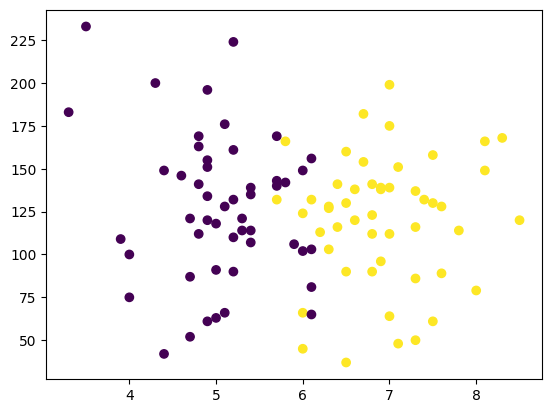

In [19]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement']) # using the third column (label) to know who got placed and who didnt

In [21]:
#Extract input and output
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [22]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:
y.shape

(100,)

In [24]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

In [25]:
X_train

,cgpa,iq
95,4.3,200.0
3,7.4,132.0
45,6.0,66.0
58,8.0,79.0
74,6.7,154.0
...,...,...
83,7.5,130.0
34,4.8,163.0
11,6.9,138.0
56,6.1,65.0


In [26]:
y_train

,placement
95,0
3,1
45,1
58,1
74,1
...,...
83,1
34,0
11,1
56,0


In [28]:
# scaling
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()

In [31]:
X_train = scaler.fit_transform(X_train)

In [32]:
X_train

array([[-1.48654427,  1.863705  ],
       [ 1.16528342,  0.17519655],
       [-0.03231618, -1.46364989],
       [ 1.6785404 , -1.14084681],
       [ 0.56648362,  0.72147869],
       [ 0.39539796, -0.86770573],
       [-0.54557315,  0.34901359],
       [ 1.76408322,  1.01945077],
       [-0.71665881,  2.45964916],
       [-0.03231618, -0.56973365],
       [-0.28894467,  0.3738446 ],
       [ 0.22431231,  0.07587252],
       [ 0.22431231, -0.54490265],
       [-0.9732873 ,  0.64698567],
       [-0.11785901, -0.47040963],
       [-0.28894467,  0.44833762],
       [-0.88774447, -0.84287473],
       [-1.14437295, -0.94219875],
       [ 0.05322665,  0.77114071],
       [ 1.33636908, -0.89253674],
       [-1.14437295, -0.09794453],
       [-0.63111598, -0.09794453],
       [-1.82871558, -0.39591661],
       [ 0.05322665, -0.54490265],
       [-0.71665881, -0.86770573],
       [ 0.73756928,  0.34901359],
       [-0.03231618, -0.02345151],
       [-0.63111598, -0.27176157],
       [ 0.56648362,

In [33]:
X_test = scaler.transform(X_test)

In [34]:
X_test

array([[-0.9732873 ,  0.22485856],
       [-0.54557315, -0.44557862],
       [ 0.05322665, -1.09118479],
       [-0.20340184,  0.42350661],
       [-0.80220164,  0.07587252],
       [-0.88774447, -1.53814291],
       [-1.14437295, -1.81128399],
       [-0.54557315,  0.24968957],
       [ 0.65202645,  0.39867561],
       [ 0.39539796,  0.12553453]])

In [35]:
from sklearn.linear_model import LogisticRegression

In [37]:
clf = LogisticRegression()

In [44]:
# model training
clf.fit(X_train, y_train.values)

LogisticRegression()

In [45]:
# Evaluate the model
y_pred = clf.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

In [47]:
accuracy_score(y_test, y_pred)

0.9

<Axes: >

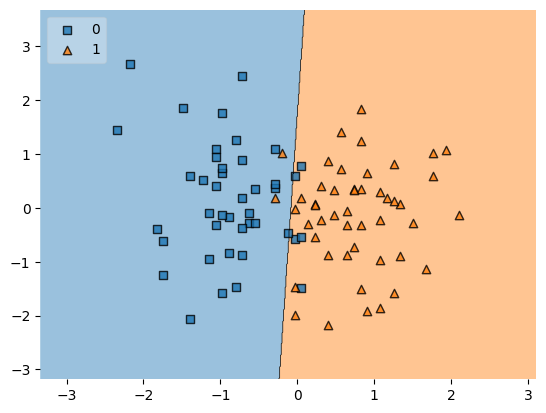

In [48]:
# plot the decision boundary
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [50]:
# save the model
import pickle
pickle.dump(clf, open('model.pkl', 'wb'))
#every thing is object so we use pickle to convert an object to file
# here dump the clf classifier object to a file model.pkl in write binary format
# file model.pkl will be created

In [51]:
# integrate this model to web page

In [ ]:
# deploy on 1. heroku 2. aws 3. gcp